<a href="https://colab.research.google.com/github/pachterlab/P_2026/blob/main/Spectral_requirements_cooperation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generate Simplex Figure


This notebook will generate Figure 1 from the paper "Spectral requirements for cooperation" by Lior Pachter. The notebook saves the figure as well as displaying it inline.

In [7]:
# Import relevant packages

import importlib
import subprocess
import sys

from IPython.display import Image, display

def ensure_package(module_name, pip_name=None):
    try:
        importlib.import_module(module_name)
    except ImportError:
        package = pip_name or module_name
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

ensure_package('numpy')
ensure_package('matplotlib')
ensure_package('scipy')

In [8]:
# Generate figure

from pathlib import Path
import math

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

OUTDIR = Path.cwd()

def barycentric_to_cartesian(q):
    v1 = np.array([0.0, 0.0])
    v2 = np.array([1.0, 0.0])
    v3 = np.array([0.5, math.sqrt(3.0) / 2.0])
    return q[0] * v1 + q[1] * v2 + q[2] * v3

def make_example():
    g = np.array([
        [0.9, 0.05, 0.05],
        [0.05, 0.55, 0.4],
        [0.05, 0.4, 0.55],
    ], dtype=float)
    b = 1.35
    c = 1.0
    pi = np.full(3, 1.0 / 3.0)
    lam_max = 0.85
    return g, b, c, pi, lam_max

def replicator_rhs(_, q, a):
    m = a @ q
    m_bar = q @ m
    return q * (m - m_bar)

def normalized(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def simplex_line_segment(q, direction):
    t_min = -np.inf
    t_max = np.inf
    for qi, di in zip(q, direction):
        if abs(di) < 1e-12:
            continue
        bound = -qi / di
        if di > 0:
            t_min = max(t_min, bound)
        else:
            t_max = min(t_max, bound)
    return q + t_min * direction, q + t_max * direction

def trajectory(a, q0, t_end=42.0):
    sol = solve_ivp(
        fun=lambda t, q: replicator_rhs(t, q, a),
        t_span=(0.0, t_end),
        y0=q0,
        dense_output=True,
        max_step=0.1,
        rtol=1e-8,
        atol=1e-10,
    )
    ts = np.linspace(0.0, t_end, 400)
    qs = sol.sol(ts).T
    return np.clip(qs, 0.0, 1.0)

def write_summary(g, pi, b, c):
    eigvals, eigvecs = np.linalg.eigh(g)
    order = np.argsort(eigvals)
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    centered_vals = eigvals[:-1]
    centered_vecs = eigvecs[:, :-1]
    lead_val = centered_vals[-1]
    lead_vec = centered_vecs[:, -1]
    summary = OUTDIR / 'example_summary.txt'
    with summary.open('w') as fh:
        fh.write('Reversible 3x3 example for the spectral theorem\n\n')
        fh.write('G =\n')
        fh.write(np.array2string(g, precision=3))
        fh.write('\n\n')
        fh.write(f'pi = {np.array2string(pi, precision=3)}\n')
        fh.write(f'b = {b:.3f}\n')
        fh.write(f'c = {c:.3f}\n\n')
        fh.write(f'eigenvalues(G) = {np.array2string(eigvals, precision=6)}\n')
        fh.write(f'leading centered eigenvalue = {lead_val:.6f}\n')
        fh.write(f'leading centered eigenvector = {np.array2string(lead_vec, precision=6)}\n')
        fh.write(f'spectral threshold: lambda_max b = {lead_val * b:.6f} > c = {c:.6f}\n')
        fh.write(f'subleading threshold: {centered_vals[0] * b:.6f} < c = {c:.6f}\n')

def make_plot(g, b, c):
    a = b * g - c * np.eye(3)
    q0 = np.array([0.14, 0.06, 0.80])
    eigvals, eigvecs = np.linalg.eigh(g)
    lead_vec = normalized(eigvecs[:, np.argsort(eigvals)[1]])
    if lead_vec[0] > 0:
        lead_vec = -lead_vec
    z = lead_vec.copy()

    traj = trajectory(a, q0)
    traj_xy = np.array([barycentric_to_cartesian(q) for q in traj])
    sample_idx = 132
    q = traj[sample_idx]
    q_xy = barycentric_to_cartesian(q)
    traj_arrow_idx = min(int(0.1 * len(traj)), len(traj) - 10)
    traj_arrow_start = traj_xy[traj_arrow_idx]
    traj_arrow_end = traj_xy[traj_arrow_idx + 8]

    dq = replicator_rhs(0.0, q, a)
    arrow_scale = 18.0
    dq_xy = barycentric_to_cartesian(q + arrow_scale * dq) - q_xy

    axis_a, axis_b = simplex_line_segment(q, lead_vec)
    axis_a_xy = barycentric_to_cartesian(axis_a)
    axis_b_xy = barycentric_to_cartesian(axis_b)

    proj_coeff = np.dot(dq, lead_vec) / np.dot(lead_vec, lead_vec)
    proj_vec = proj_coeff * lead_vec
    proj_tip = q + arrow_scale * proj_vec
    proj_xy = barycentric_to_cartesian(proj_tip) - q_xy

    pts = []
    vals = []
    grid_n = 90
    for i in range(grid_n + 1):
        for j in range(grid_n + 1 - i):
            x = np.array([i / grid_n, j / grid_n, 1.0 - (i + j) / grid_n])
            pts.append(barycentric_to_cartesian(x))
            vals.append(x @ z)
    pts = np.array(pts)
    vals = np.array(vals)

    fig, ax = plt.subplots(figsize=(8.0, 6.8))
    ax.tricontourf(pts[:, 0], pts[:, 1], vals, levels=30, alpha=0.35, cmap='YlGnBu')

    triangle = np.array([
        barycentric_to_cartesian(np.array([1.0, 0.0, 0.0])),
        barycentric_to_cartesian(np.array([0.0, 1.0, 0.0])),
        barycentric_to_cartesian(np.array([0.0, 0.0, 1.0])),
        barycentric_to_cartesian(np.array([1.0, 0.0, 0.0])),
    ])
    ax.plot(triangle[:, 0], triangle[:, 1], color='black', lw=1.8)

    vertex_labels = [
        ('1', barycentric_to_cartesian(np.array([1.0, 0.0, 0.0])), (-7, -5), 'right', 'top'),
        ('2', barycentric_to_cartesian(np.array([0.0, 1.0, 0.0])), (7, -5), 'left', 'top'),
        ('3', barycentric_to_cartesian(np.array([0.0, 0.0, 1.0])), (0, 7), 'center', 'bottom'),
    ]
    for label, pos, offset_pts, ha, va in vertex_labels:
        ax.annotate(
            label,
            xy=pos,
            xytext=offset_pts,
            textcoords='offset points',
            fontsize=14,
            fontweight='bold',
            ha=ha,
            va=va,
            color='black',
            annotation_clip=False,
        )

    ax.plot(traj_xy[:, 0], traj_xy[:, 1], color='black', lw=2.2)
    ax.annotate('', xy=traj_arrow_end, xytext=traj_arrow_start, arrowprops=dict(arrowstyle='-|>', lw=2.0, color='black'))
    ax.scatter([q_xy[0]], [q_xy[1]], s=52, color='#2563eb', zorder=5)
    ax.annotate('', xy=q_xy + dq_xy, xytext=q_xy, arrowprops=dict(arrowstyle='-|>', lw=3.4, color='#dc2626'))
    ax.plot([axis_a_xy[0], axis_b_xy[0]], [axis_a_xy[1], axis_b_xy[1]], linestyle=(0, (6, 4)), color='#7c3aed', lw=2.0)
    ax.annotate('', xy=q_xy + proj_xy, xytext=q_xy, arrowprops=dict(arrowstyle='-|>', lw=3.0, color='#0f766e'))

    ax.set_aspect('equal')
    ax.set_xlim(-0.06, 1.06)
    ax.set_ylim(-0.06, math.sqrt(3.0) / 2.0 + 0.08)
    ax.axis('off')
    fig.tight_layout()

    outpath = OUTDIR / 'reversible_3x3_simplex_colab.png'
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    return outpath

g, b, c, pi, _ = make_example()
write_summary(g, pi, b, c)
outpath = make_plot(g, b, c)
print(f'Wrote figure to {outpath}')

Wrote figure to /content/reversible_3x3_simplex_colab.png


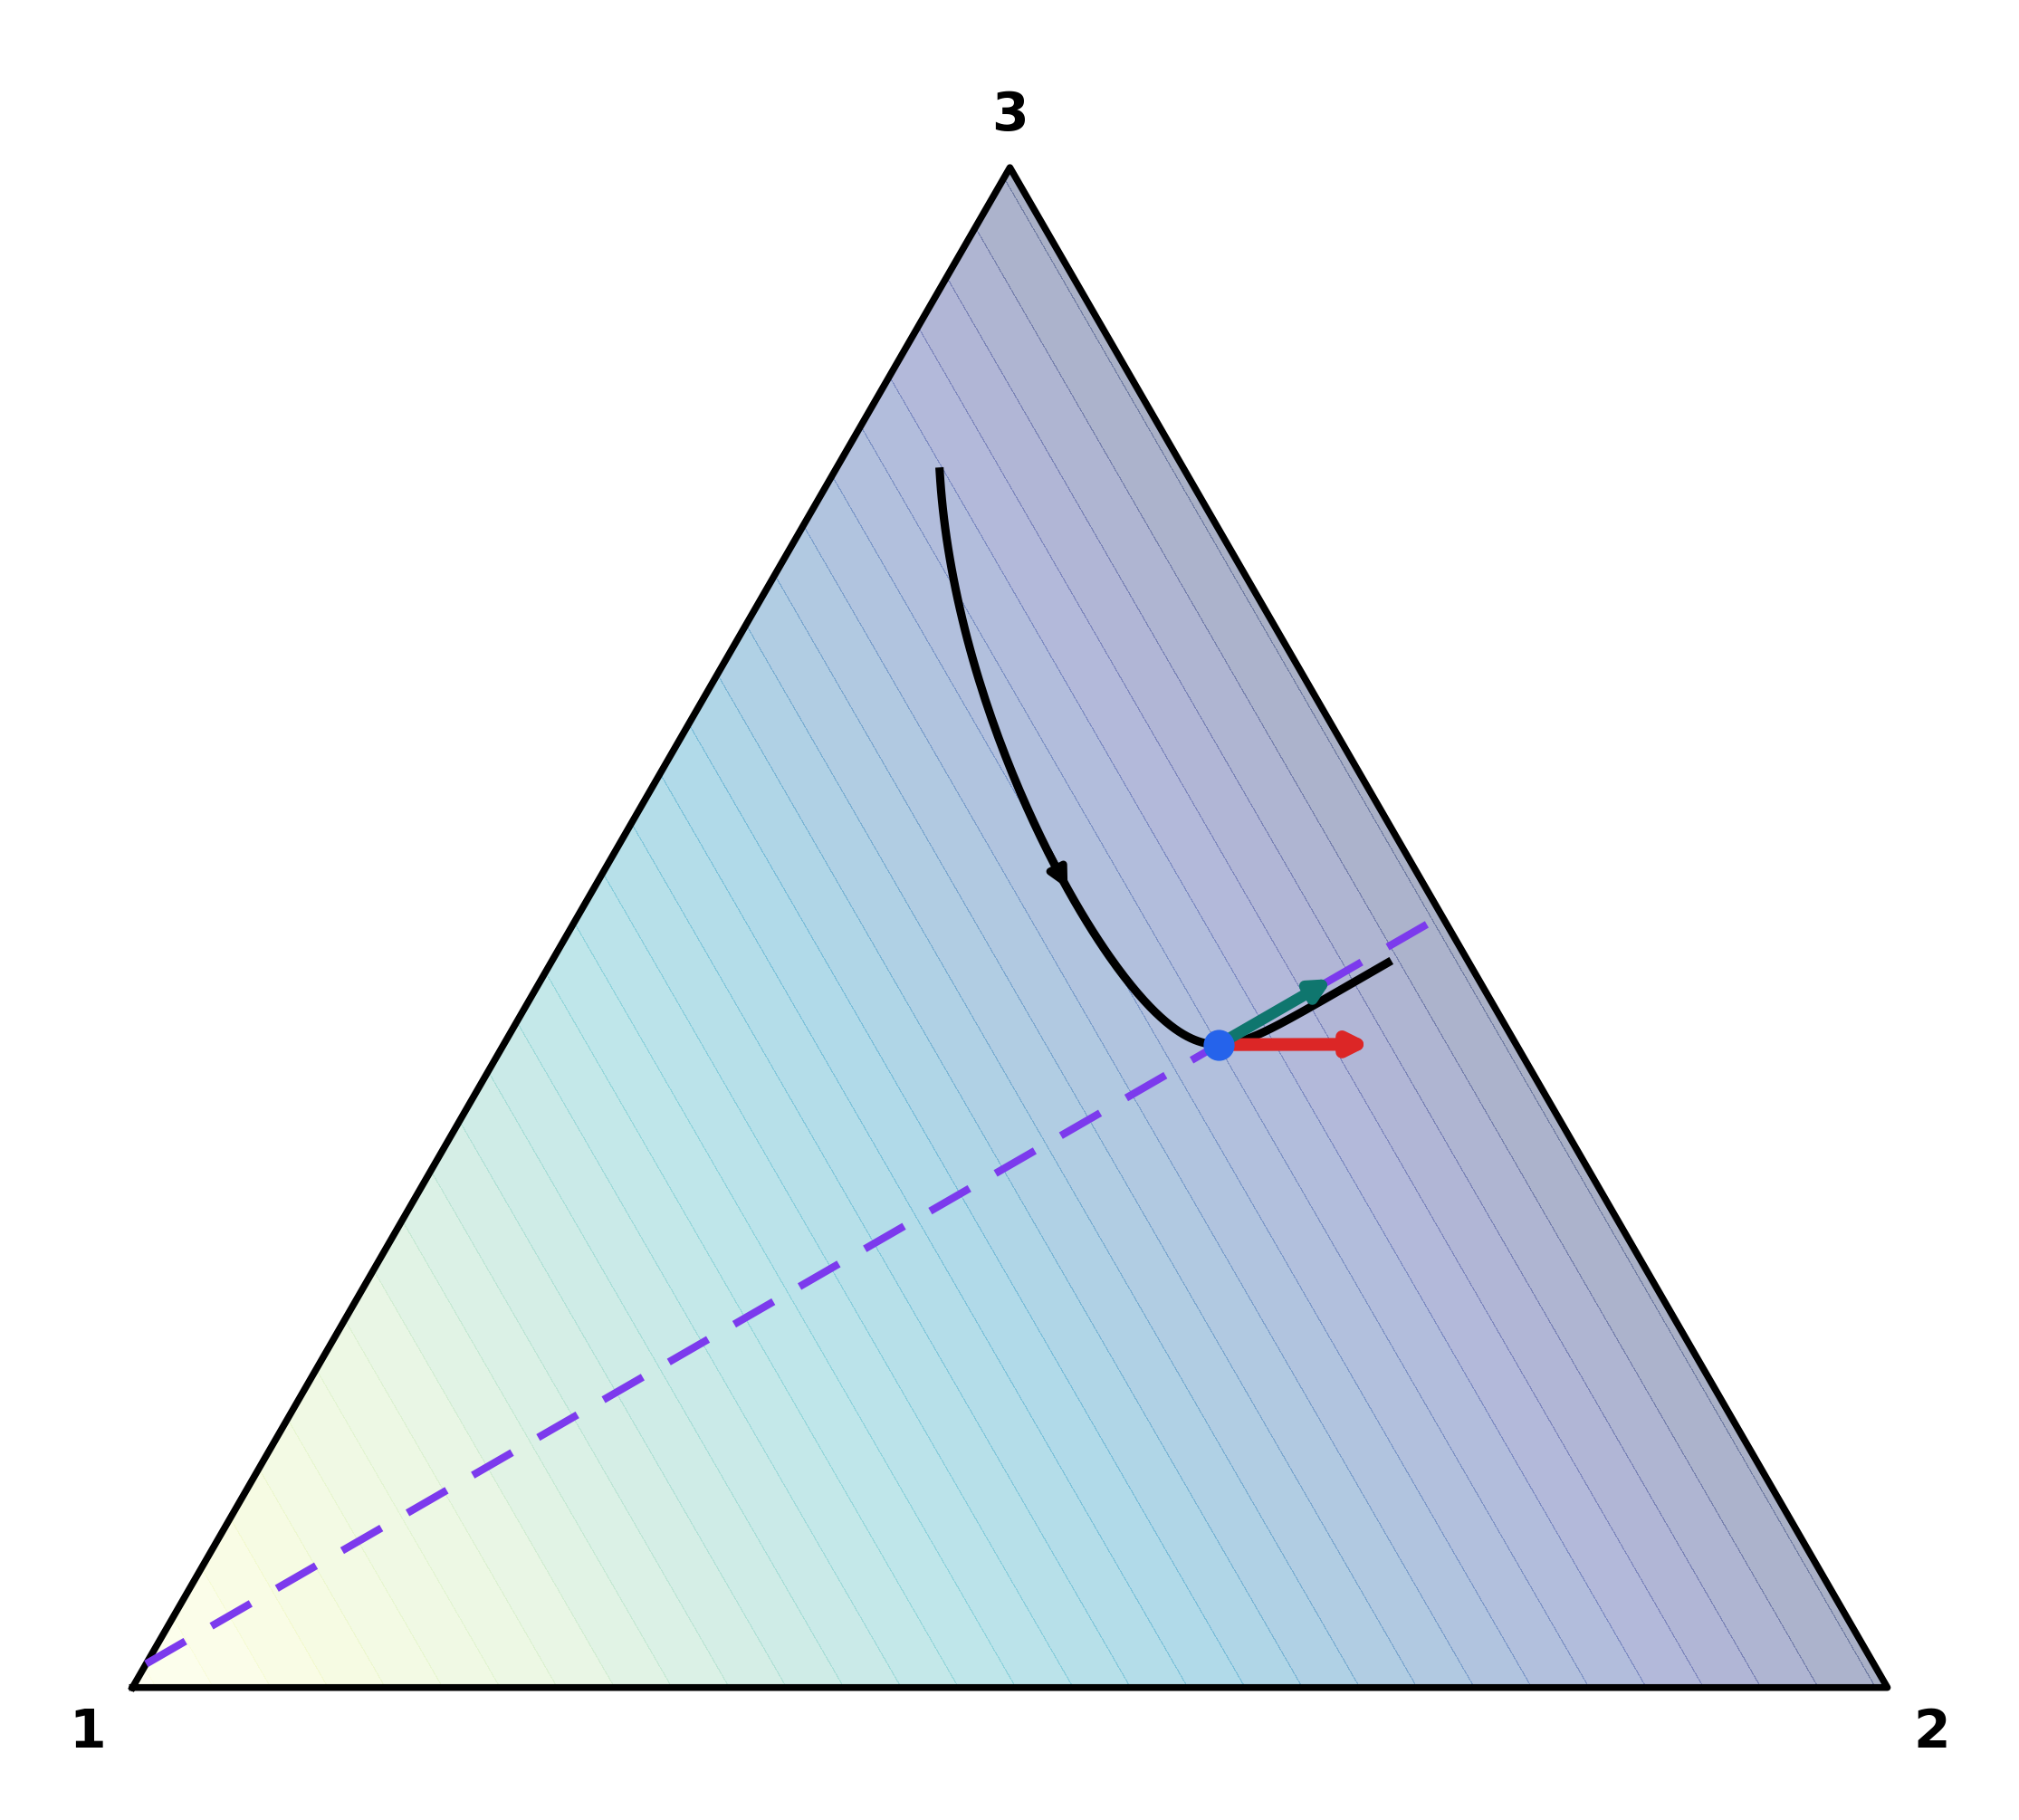

In [6]:
  display(Image(filename=str(outpath), width=800))
